### Application 授信結果預測專案：EDA 與資料流程建置

notebook 目標：
1. 讀取原始 CSV 資料
2. 進行基礎 EDA 與資料品質檢查
3. 建立 Bronze / Silver / Gold 分層資料流程
4. 切分 development 與 final OOT dataset
5. 建立 rolling training-monitoring window 定義

專案設定：
- 1 row = 1 application
- label = 授信結果
- 案件編號不作為模型特徵

- 全資料 24 個月
- 前 18 個月：development
- 後 6 個月：final OOT
- development 內：
  - 4 個月 training window
  - training window 內做 time-based CV
  - 接 2 個月 monitoring window

In [1]:
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, DoubleType

import matplotlib.pyplot as plt

In [2]:
# Ensure Matplotlib can render Chinese text on Windows
import matplotlib as mpl
from matplotlib import font_manager

candidate_fonts = [
    "Microsoft JhengHei",  # 微軟正黑體
    "Microsoft YaHei",     # 微軟雅黑
    "SimHei",             # 黑體
    "PMingLiU",           # 新細明體
]

available = {f.name for f in font_manager.fontManager.ttflist}
font_to_use = next((f for f in candidate_fonts if f in available), None)

if font_to_use is None:
    print("No common Chinese font found. You may need to install one (e.g., Microsoft JhengHei).")
else:
    mpl.rcParams["font.family"] = font_to_use
    mpl.rcParams["axes.unicode_minus"] = False
    print("Using Matplotlib font:", font_to_use)

Using Matplotlib font: Microsoft JhengHei


In [3]:
spark = SparkSession.builder \
    .appName("application_probability_pipeline_eda") \
    .getOrCreate()

print(spark)

In [4]:
from pathlib import Path

# Resolve project root (../ from this notebook file) so relative paths work no matter CWD
project_root = Path.cwd()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

raw_file_path = project_root / "data" / "raw" / "application_data.csv"

bronze_output_path = project_root / "data" / "bronze" / "bronze_application_raw.parquet"
silver_output_path = project_root / "data" / "silver" / "silver_application_clean.parquet"

gold_model_base_path = project_root / "data" / "gold" / "gold_application_model_base.parquet"
gold_dev_path = project_root / "data" / "gold" / "gold_development_dataset.parquet"
gold_oot_path = project_root / "data" / "gold" / "gold_final_oot_dataset.parquet"
gold_window_def_path = project_root / "data" / "gold" / "gold_rolling_window_definition.parquet"

print("project_root:", project_root)
print("raw_file_path:", raw_file_path)

project_root: c:\Users\88696\Desktop\ml_project
raw_file_path: c:\Users\88696\Desktop\ml_project\data\raw\application_data.csv


In [5]:
# Load raw dataset (CSV)
if not raw_file_path.exists():
    raise FileNotFoundError(
        f"Raw file not found: {raw_file_path}. "
        "Check the working directory and the 'data/raw' folder."
    )

df_pd = pd.read_csv(raw_file_path.as_posix(), encoding="utf-8-sig")
print(df_pd.shape)
print(df_pd.columns.tolist())
df_pd.head()

(184051, 19)
['案件編號', '進件日', '申辦期數', '原申辦金額', '性別', '年齡', '教育程度', '婚姻狀況', '月所得', '車齡', '職業說明', '居住地', '所留市內電話數', '內部往來次數', '近半年同業查詢次數', '廠牌車型', '動產設定', '授信結果', '成功案例']


,案件編號,進件日,申辦期數,原申辦金額,性別,年齡,教育程度,婚姻狀況,月所得,車齡,職業說明,居住地,所留市內電話數,內部往來次數,近半年同業查詢次數,廠牌車型,動產設定,授信結果,成功案例
0,FT13310976,20240401,12.0,61000,男,60,NaN,未婚,"20,000~24,999",-1.0,批發及零售業(流動攤販),高雄縣,1,1,1,山葉,0,APP(核准),1
1,FT13311221,20240401,12.0,61000,女,53,NaN,未婚,"55,000~59,999",-1.0,專業服務業(護士),高雄市,0,0,1,山葉,0,APP(核准),1
2,FT13400005,20240401,36.0,117000,男,20,NaN,未婚,"20,000以下",-1.0,學生(大專生),台北市,1,0,1,三陽,0,APP(核准),1
3,FT13400006,20240401,24.0,109800,男,28,NaN,未婚,"50,000~54,999",-1.0,製造業(電子業),台南市,1,0,1,三陽,0,APP(核准),1
4,FT13400007,20240401,24.0,109800,男,27,NaN,未婚,"30,000~34,999",-1.0,製造業(塑膠橡膠業),雲林縣,0,0,1,三陽,0,APP(核准),1


In [6]:
df_pd.info()

<class 'pandas.DataFrame'>
RangeIndex: 184051 entries, 0 to 184050
Data columns (total 19 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   案件編號       184051 non-null  str    
 1   進件日        184051 non-null  int64  
 2   申辦期數       183891 non-null  float64
 3   原申辦金額      184051 non-null  int64  
 4   性別         184051 non-null  str    
 5   年齡         184051 non-null  int64  
 6   教育程度       30312 non-null   str    
 7   婚姻狀況       180104 non-null  str    
 8   月所得        179960 non-null  str    
 9   車齡         184051 non-null  float64
 10  職業說明       184033 non-null  str    
 11  居住地        183631 non-null  str    
 12  所留市內電話數    184051 non-null  int64  
 13  內部往來次數     184051 non-null  int64  
 14  近半年同業查詢次數  184051 non-null  int64  
 15  廠牌車型       183977 non-null  str    
 16  動產設定       184051 non-null  int64  
 17  授信結果       184051 non-null  str    
 18  成功案例       184051 non-null  int64  
dtypes: float64(2), int64(8), str(9)
me

In [7]:
print("授信結果分布：")
print(df_pd["授信結果"].value_counts(dropna=False))

print("\n進件日範例：")
print(df_pd["進件日"].head())

授信結果分布：
授信結果
APP(核准)     175463
WTCD(婉拒)      8588
Name: count, dtype: int64

進件日範例：
0    20240401
1    20240401
2    20240401
3    20240401
4    20240401
Name: 進件日, dtype: int64


In [8]:
df_pd["進件日"] = pd.to_datetime(df_pd["進件日"].astype(str), format="%Y%m%d", errors="coerce")

print("日期範圍：")
print(df_pd["進件日"].min(), "to", df_pd["進件日"].max())

日期範圍：
2024-04-01 00:00:00 to 2026-03-31 00:00:00


EDA

In [9]:
missing_ratio = df_pd.isna().mean().sort_values(ascending=False)
missing_ratio

教育程度         0.835307
月所得          0.022228
婚姻狀況         0.021445
居住地          0.002282
申辦期數         0.000869
廠牌車型         0.000402
職業說明         0.000098
進件日          0.000000
案件編號         0.000000
年齡           0.000000
性別           0.000000
車齡           0.000000
原申辦金額        0.000000
內部往來次數       0.000000
所留市內電話數      0.000000
近半年同業查詢次數    0.000000
動產設定         0.000000
授信結果         0.000000
成功案例         0.000000
dtype: float64

In [10]:
dup_count = df_pd["案件編號"].duplicated().sum()
print("案件編號重複筆數：", dup_count)

案件編號重複筆數： 0


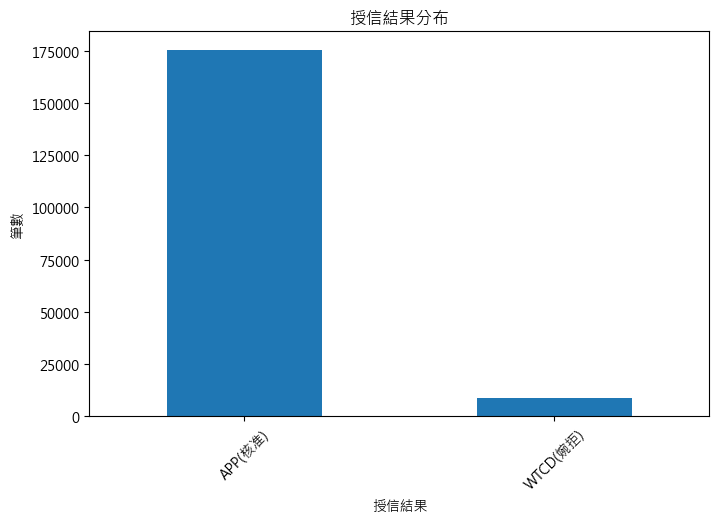

In [11]:
label_counts = df_pd["授信結果"].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")
plt.title("授信結果分布")
plt.ylabel("筆數")
plt.xticks(rotation=45)
plt.show()

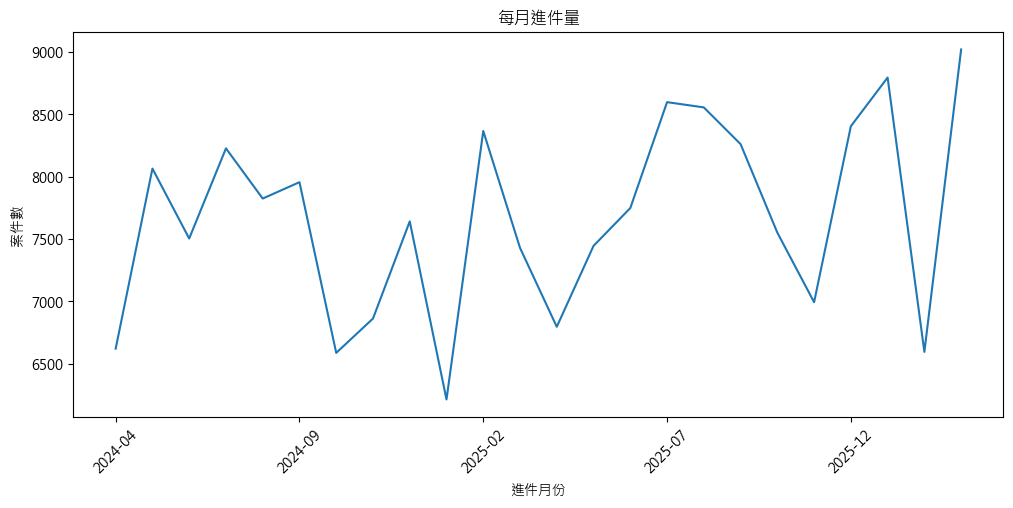

In [12]:
monthly_counts = (
    df_pd.dropna(subset=["進件日"])
         .assign(進件月份=df_pd["進件日"].dt.to_period("M").astype(str))
         .groupby("進件月份")
         .size()
)

plt.figure(figsize=(12, 5))
monthly_counts.plot()
plt.title("每月進件量")
plt.ylabel("案件數")
plt.xticks(rotation=45)
plt.show()

In [13]:
monthly_label = (
    df_pd.dropna(subset=["進件日"])
         .assign(進件月份=df_pd["進件日"].dt.to_period("M").astype(str))
         .groupby(["進件月份", "授信結果"])
         .size()
         .unstack(fill_value=0)
)

monthly_label.head()

授信結果,APP(核准),WTCD(婉拒)
進件月份,,
2024-04,6320,302
2024-05,7676,388
2024-06,7220,284
2024-07,7912,314
2024-08,7460,364


In [18]:
numeric_cols = [
    "申辦期數", "原申辦金額", "年齡", "車齡",
    "所留市內電話數", "內部往來次數", "近半年同業查詢次數"
]

df_pd[numeric_cols].describe()

,申辦期數,原申辦金額,年齡,車齡,所留市內電話數,內部往來次數,近半年同業查詢次數
count,183891.000000,1.840510e+05,184051.000000,184051.000000,184051.000000,184051.000000,184051.000000
mean,25.212691,9.033868e+04,36.986286,-0.803049,0.505930,0.280585,1.254234
std,8.098861,2.456013e+04,13.986501,2.325460,0.567078,0.749797,1.112855
min,3.000000,6.000000e+03,0.000000,-56.000000,0.000000,0.000000,-1.000000
25%,24.000000,7.030000e+04,24.000000,-1.000000,0.000000,0.000000,1.000000
50%,24.000000,8.850000e+04,37.000000,-1.000000,0.000000,0.000000,1.000000
75%,36.000000,1.113000e+05,47.000000,-1.000000,1.000000,0.000000,1.000000
max,72.000000,1.470000e+06,88.000000,875.050000,5.000000,67.000000,40.000000


In [19]:
category_cols = [
    "性別", "教育程度", "婚姻狀況", "職業說明","月所得",
    "居住地", "廠牌車型", "動產設定", "授信結果"
]

for col in category_cols:
    print(f"\n==== {col} ====")
    print(df_pd[col].value_counts(dropna=False).head(10))


==== 性別 ====
性別
男    106094
女     77957
Name: count, dtype: int64

==== 教育程度 ====
教育程度
NaN     153739
高中       12657
大學       10138
專科        4369
國中        1192
碩士        1032
其他         782
博士以上       142
Name: count, dtype: int64

==== 婚姻狀況 ====
婚姻狀況
未婚     111811
已婚      68212
NaN      3947
同居         77
離婚          4
Name: count, dtype: int64

==== 職業說明 ====
職業說明
工商服務類                     28347
製造業                       24238
學生(大專生)                   18631
住宿及餐飲業                    12836
營造業                        8187
學生(高中職生)                   7409
批發及零售業                     6318
製造業(電子業)                   5298
其他(家庭主婦、家庭代工)              4423
公私立學校教育機構(幼稚園.托兒所.安親班)     3801
Name: count, dtype: int64

==== 月所得 ====
月所得
30,000~34,999    74544
20,000~24,999    26705
40,000~44,999    14668
35,000~39,999    14472
50,000~54,999    10832
25,000~29,999     8313
45,000~49,999     8041
60,000~64,999     5296
80,000~           5210
20,000以下          4473
Name: count, dtype: int64

==== 居

In [16]:
# ========================================
# 資料清理: 從「職業說明」補回「教育程度」
# ========================================

def fill_education_from_occupation(row):
    """
    如果教育程度是 NaN，且職業是學生，則根據學生類型填入對應教育程度
    """
    if pd.isna(row["教育程度"]):
        occupation = str(row["職業說明"]) if pd.notna(row["職業說明"]) else ""
        if "學生(大專生)" in occupation or "大學生" in occupation:
            return "大學"
        elif "學生(高中職生)" in occupation or "高中生" in occupation:
            return "高中"
        elif "國中生" in occupation:
            return "國中"
        elif "研究生" in occupation or "碩士" in occupation:
            return "碩士"
    return row["教育程度"]

# 套用清理邏輯
df_pd["教育程度_cleaned"] = df_pd.apply(fill_education_from_occupation, axis=1)

# 比較清理前後
print("=" * 50)
print("清理前 - 教育程度缺失率:", df_pd["教育程度"].isna().mean())
print("清理後 - 教育程度缺失率:", df_pd["教育程度_cleaned"].isna().mean())
print()
print("清理後教育程度分布:")
print(df_pd["教育程度_cleaned"].value_counts(dropna=False))

清理前 - 教育程度缺失率: 0.8353065183019924
清理後 - 教育程度缺失率: 0.7204796496623218

清理後教育程度分布:
教育程度_cleaned
NaN     132605
大學       24916
高中       18598
專科        4369
碩士        1447
國中        1192
其他         782
博士以上       142
Name: count, dtype: int64


In [17]:
# ========================================
# 廠牌車型 vs 授信結果 交叉分析
# ========================================

brand_approval = (
    df_pd.groupby("廠牌車型")["授信結果"]
    .apply(lambda x: (x == "APP(核准)").mean())
    .sort_values(ascending=False)
)

print("各廠牌核准率:")
print(brand_approval)
print()
print(f"核准率範圍: {brand_approval.min():.1%} ~ {brand_approval.max():.1%}")
print(f"核准率差異: {brand_approval.max() - brand_approval.min():.1%}")
print()
print("→ 廠牌車型對授信結果有區別力，可作為特徵使用")

各廠牌核准率:
廠牌車型
2            1.000000
202509       1.000000
202512       1.000000
202602       1.000000
APRILIA      1.000000
CPI          1.000000
HUSQVARNA    1.000000
KTM          1.000000
其他機車廠牌       1.000000
中華機車         1.000000
星大洋          1.000000
雍御           1.000000
台崎           1.000000
捷穎           1.000000
水牛牌          1.000000
台鈴           0.967916
三陽           0.964093
HONDA        0.959322
比雅久          0.949662
光陽           0.947280
山葉           0.940984
宏佳騰          0.932432
本田           0.931818
KAWASAKI     0.913043
SUZUKI       0.913043
哈特佛          0.869565
其他重機廠牌       0.857143
VESPA        0.851429
BENELLI      0.833333
電動機車         0.832389
CFMOTO       0.818182
其它           0.814815
BRIXTON      0.800000
睿能           0.675958
其他汽車廠牌       0.600000
光大           0.500000
LAMBRETTA    0.000000
Name: 授信結果, dtype: float64

核准率範圍: 0.0% ~ 100.0%
核准率差異: 100.0%

→ 廠牌車型對授信結果有區別力，可作為特徵使用


### EDA 結論摘要

#### 資料概覽
- **總筆數**: 184,051 筆 (1 row = 1 application)
- **時間範圍**: 24 個月
- **Label 分布**: APP(核准) 175,463 (95.3%) vs WTCD(婉拒) 8,588 (4.7%) → **高度不平衡**

#### 欄位缺失率
| 欄位 | 缺失率 | 處理建議 |
|------|--------|----------|
| 教育程度 | **83.5%** | 缺失嚴重，但可從「職業說明」補回學生 |
| 月所得 | 2.2% | 可填補或保留 |
| 婚姻狀況 | 2.1% | 可填補或保留 |
| 其他欄位 | < 1% | 正常 |

#### 特徵使用

| 欄位 | 建議 | 說明 |
|------|------|------|
| ✅ 申辦期數 | 使用 | 數值型，分布合理 (3~72 期) |
| ✅ 原申辦金額 | 使用 | 數值型，需注意極端值 (max 147 萬) |
| ✅ 性別 | 使用 | 完整，二元類別 |
| ✅ 年齡 | 使用 | 完整，需檢查 小於 18 歲異常值 |
| ⚠️ 教育程度 | 使用(需清理) | 缺失 83%，但學生可從職業補回 ,但填補後能有79% 的缺失 | 
| ✅ 婚姻狀況 | 使用 | 缺失 2%，可處理 |
| ⚠️ 月所得 | 使用(需清理) | 區間文字需轉數值 |
| ⚠️ 車齡 | 謹慎使用 | 負值 (-56) 需確認定義，可能是「新車」指標, 以及最大值875.050000, -1 是缺失 | 
| ✅ 職業說明 | 使用 | 高基數類別，需分群 |
| ✅ 居住地 | 使用 | 地區類別，可分群 |
| ✅ 所留市內電話數 | 使用 | 數值型 |
| ✅ 內部往來次數 | 使用 | 數值型 | -1.000000 需重新定義
| ✅ 近半年同業查詢次數 | 使用 | 數值型，信用相關重要特徵 |
| ✅ 廠牌車型 | **可使用** | 低基數 (~10 類)，可能反映客群特性 |
| ✅ 動產設定 | 使用 | 二元 (0/1) |
| ❌ 案件編號 | 不使用 | ID 欄位 |
| ❌ 成功案例 | 不使用 | 可能是 label leakage |

#### 特別注意
**Label imbalance**: 核准率 95%，需考慮 resampling 或調整 class weight

In [20]:
spark.stop()